# 05: Merge Tagged Data and Baseline Sentiment Model

This notebook combines the two completed tagging stages and builds the first baseline sentiment models.

Inputs:

```text
../data/processed/manual_tagging_analysis_ready.csv
../data/processed/manual_tagging_batch_02_tagged_assistant.csv
```

Main merged output:

```text
../data/processed/combined_tagged_reviews_after_batch02.csv
```

The notebook focuses on:

1. loading the combined tagged dataset
2. checking manual label distribution
3. comparing Steam recommendation labels with manual sentiment
4. building a simple non-ML baseline from the Steam label
5. training a TF-IDF + Logistic Regression baseline
6. evaluating the model with classification reports and confusion matrices
7. inspecting wrong predictions
8. exporting model-ready data and prediction outputs

> This is still a baseline stage. The goal is not to build the best possible model yet, but to create an interpretable benchmark.

## 0. Why This Phase Matters

This project is not only about sentiment classification.

The core question is:

```text
Apakah label Recommended / Not Recommended di Steam benar-benar merepresentasikan sentimen teks review?
```

Because of that, the analysis compares:

```text
Steam recommendation label
vs
Manual actual_sentiment
vs
Model prediction from review text
```

If a text-based model can capture signals behind labels such as `Mixed`, `Mourning`, or `Soft Mismatch`, the project becomes stronger than a simple EDA-only analysis.

In [17]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

DATA_PROCESSED = Path("../data/processed")
MODELS_DIR = Path("../models")

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_colwidth", 300)
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Merge the Completed Tagged Datasets

The pilot tagging stage contains 38 reviews, while Batch 02 contains 133 reviews.

This step aligns both schemas, records the annotation source, and combines them into one tagged dataset for modeling.


In [18]:
PILOT_TAGGED_PATH = (
    DATA_PROCESSED
    / "manual_tagging_analysis_ready.csv"
)

BATCH_02_TAGGED_PATH = (
    DATA_PROCESSED
    / "manual_tagging_batch_02_tagged_assistant.csv"
)

COMBINED_OUTPUT_PATH = (
    DATA_PROCESSED
    / "combined_tagged_reviews_after_batch02.csv"
)

MODEL_READY_PATH = (
    DATA_PROCESSED
    / "combined_tagged_reviews_model_ready.csv"
)

BINARY_PREDICTIONS_PATH = (
    DATA_PROCESSED
    / "binary_sentiment_predictions.csv"
)

MULTICLASS_PREDICTIONS_PATH = (
    DATA_PROCESSED
    / "multiclass_sentiment_predictions.csv"
)

MODEL_PATH = (
    MODELS_DIR
    / "baseline_binary_sentiment_tfidf_logreg.joblib"
)

required_input_paths = [
    PILOT_TAGGED_PATH,
    BATCH_02_TAGGED_PATH
]

missing_input_paths = [
    path for path in required_input_paths
    if not path.exists()
]

if missing_input_paths:
    missing_text = "\n".join(
        str(path) for path in missing_input_paths
    )
    raise FileNotFoundError(
        "Required tagged input files were not found:\n"
        f"{missing_text}"
    )

pilot_df = pd.read_csv(
    PILOT_TAGGED_PATH,
    encoding="utf-8-sig"
)

batch_02_df = pd.read_csv(
    BATCH_02_TAGGED_PATH,
    encoding="utf-8-sig"
)

pilot_df.columns = [
    str(col).replace("\ufeff", "").strip()
    for col in pilot_df.columns
]

batch_02_df.columns = [
    str(col).replace("\ufeff", "").strip()
    for col in batch_02_df.columns
]

# Align the pilot category fields with the Batch 02 schema.
if "primary_category" not in pilot_df.columns:
    pilot_df["primary_category"] = (
        pilot_df["review_category"]
        .fillna("")
        .astype(str)
        .str.split(";")
        .str[0]
        .str.strip()
    )

if "secondary_category" not in pilot_df.columns:
    pilot_df["secondary_category"] = (
        pilot_df["review_category"]
        .fillna("")
        .astype(str)
        .apply(
            lambda value: (
                value.split(";", 1)[1].strip()
                if ";" in value
                else pd.NA
            )
        )
    )

if "annotation_confidence" not in pilot_df.columns:
    pilot_df["annotation_confidence"] = (
        pilot_df["actual_sentiment"].map({
            "Positive": "High",
            "Negative": "High",
            "Mixed": "Medium",
            "Neutral/Unclear": "Low"
        })
    )

pilot_df["annotation_source"] = "pilot_manual"

if "annotation_source" not in batch_02_df.columns:
    batch_02_df["annotation_source"] = "assistant_draft"
else:
    batch_02_df["annotation_source"] = (
        batch_02_df["annotation_source"]
        .fillna("assistant_draft")
        .replace("", "assistant_draft")
    )

# Keep the Batch 02 schema first, followed by pilot-only columns.
combined_columns = (
    list(batch_02_df.columns)
    +
    [
        col for col in pilot_df.columns
        if col not in batch_02_df.columns
    ]
)

df = pd.concat(
    [
        pilot_df.reindex(columns=combined_columns),
        batch_02_df.reindex(columns=combined_columns)
    ],
    ignore_index=True
)

# Keep optional Boolean fields readable after schema alignment.
optional_boolean_columns = [
    "contains_update_keyword",
    "contains_bug_or_degradation",
    "is_mourning",
    "is_low_information",
    "is_soft_mismatch_candidate",
    "is_veteran",
    "contains_update_keyword_refined",
    "contains_bug_or_degradation_keyword",
    "is_mourning_refined",
    "is_mismatch_candidate"
]

def normalize_optional_boolean(value):
    if pd.isna(value):
        return pd.NA

    if isinstance(value, bool):
        return value

    normalized = str(value).strip().lower()

    if normalized in {"true", "1", "1.0"}:
        return True

    if normalized in {"false", "0", "0.0"}:
        return False

    return pd.NA

for col in optional_boolean_columns:
    if col in df.columns:
        df[col] = (
            df[col]
            .map(normalize_optional_boolean)
            .astype("boolean")
        )

df.to_csv(
    COMBINED_OUTPUT_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Pilot tagged rows:", len(pilot_df))
print("Batch 02 tagged rows:", len(batch_02_df))
print("Combined tagged rows:", len(df))
print(
    f"Saved combined tagged dataset to: "
    f"{COMBINED_OUTPUT_PATH}"
)

display(df.head())
display(df["annotation_source"].value_counts())


Pilot tagged rows: 38
Batch 02 tagged rows: 133
Combined tagged rows: 171
Saved combined tagged dataset to: ..\data\processed\combined_tagged_reviews_after_batch02.csv


,game_title,review_date,recommendation,playtime_raw,playtime_hours,playtime_segment,helpful_count,funny_count,weighted_vote_score,comment_count,...,annotation_confidence,annotation_source,author_name,is_veteran,word_count,contains_update_keyword_refined,contains_bug_or_degradation_keyword,is_mourning_refined,is_mismatch_candidate,review_category
0,Phasmophobia,Posted: 12 May,Not Recommended,NaN,77.1,Regular,0,0,NaN,NaN,...,High,pilot_manual,Clown,False,17.0,True,True,False,False,Update Backlash; Sarcasm / Bug Complaint
1,Phasmophobia,Posted: 12 May,Not Recommended,NaN,23.5,Casual,3,0,NaN,NaN,...,High,pilot_manual,Eggis,False,13.0,True,False,False,False,Update Backlash; Mourning-lite
2,Phasmophobia,Posted: May 12,Not Recommended,NaN,65.4,Regular,4,0,NaN,NaN,...,High,pilot_manual,Tracker,False,166.0,True,True,False,False,Update Backlash; Developer Criticism
3,Phasmophobia,Posted: May 12,Not Recommended,NaN,470.5,Hardcore,0,0,NaN,NaN,...,High,pilot_manual,King Chonk,True,149.0,True,True,False,False,Update Backlash; Bug / Gameplay Degradation
4,Phasmophobia,Posted: May 12,Not Recommended,NaN,476.6,Hardcore,3,0,NaN,NaN,...,High,pilot_manual,Scout,True,418.0,True,True,False,False,Mourning; Update Backlash


annotation_source
assistant_draft    133
pilot_manual        38
Name: count, dtype: int64

## 2. Basic Cleaning and Schema Normalization

The combined tagging file may contain columns from different tagging stages. This step normalizes the basic schema before modeling.

In [19]:
df = df.copy()

# Fix BOM / weird column issues if any
df.columns = [str(col).replace("\ufeff", "").strip() for col in df.columns]

# Ensure important columns exist
required_columns = {
    "analysis_review": "",
    "recommendation": "",
    "actual_sentiment": "",
    "primary_category": "",
    "secondary_category": "",
    "annotation_notes": "",
    "mismatch_type": "",
    "annotation_confidence": "",
    "playtime_hours": 0,
    "helpful_count": 0,
    "funny_count": 0
}

for col, default in required_columns.items():
    if col not in df.columns:
        df[col] = default

# Fallback if analysis_review is missing but older text columns exist
if df["analysis_review"].fillna("").str.strip().eq("").all():
    for fallback_col in ["cleaned_review", "review_text"]:
        if fallback_col in df.columns:
            df["analysis_review"] = df[fallback_col]
            break

def normalize_text(text):
    if not isinstance(text, str):
        return ""

    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["analysis_review"] = df["analysis_review"].apply(normalize_text)
df["actual_sentiment"] = df["actual_sentiment"].fillna("").astype(str).str.strip()
df["recommendation"] = df["recommendation"].fillna("").astype(str).str.strip()

# Remove empty text / empty label rows
before_filter = len(df)

df = df[
    (df["analysis_review"] != "")
    &
    (df["actual_sentiment"] != "")
].copy()

print("Rows removed due to empty text or label:", before_filter - len(df))

# Deduplicate by normalized review text
df["review_dedup_key"] = (
    df["analysis_review"]
    .str.lower()
    .str.strip()
)

before_dedup = len(df)

df = (
    df
    .drop_duplicates(subset=["review_dedup_key"])
    .reset_index(drop=True)
)

print("Rows before dedup:", before_dedup)
print("Rows after dedup:", len(df))
print("Duplicates removed:", before_dedup - len(df))

display(df[["recommendation", "actual_sentiment", "primary_category", "analysis_review"]].head())

Rows removed due to empty text or label: 0
Rows before dedup: 171
Rows after dedup: 171
Duplicates removed: 0


,recommendation,actual_sentiment,primary_category,analysis_review
0,Not Recommended,Negative,Update Backlash,Rushed out a buggy and broken update so they could do an Alan Wake (2) collab. Marvelous.
1,Not Recommended,Negative,Update Backlash,The latest update has ruined the experience for me ( bendy back gone)
2,Not Recommended,Negative,Update Backlash,This last update was a mess. It's been on the roadmap since 2022 yet the devs keep saying it was rushed at every turn. An update that is a flawed mess of so called features. If you like awful AI like animations and a dev team that will lie about the poor quality of updates and then deflect when ...
3,Not Recommended,Negative,Update Backlash,"TL;DR Don't get it yet character customization added animations that made it so sluggish I have played this game for many hours, maybe not as much as some of the community but still enough to enjoy my time with this game, I have been through the janky times of when the game first came out and I ..."
4,Not Recommended,Negative,Mourning,"I used to really love playing this game, but it seems the devs have just been making questionable decisions ever since the item update. Rather than rework maps that no one likes, like school or prison, they reworked a beloved map. I actually like new Tanglewood, but it feels like they only did t..."


## 3. Label Distribution Check

Before modeling, the label distribution needs to be checked so the baseline results are easier to interpret.

In [20]:
print("Total tagged reviews:", len(df))

print("\nSteam recommendation distribution:")
display(df["recommendation"].value_counts())

print("\nManual actual_sentiment distribution:")
display(df["actual_sentiment"].value_counts())

print("\nPrimary category distribution:")
display(df["primary_category"].value_counts())

print("\nAnnotation confidence:")
if "annotation_confidence" in df.columns:
    display(df["annotation_confidence"].value_counts())

print("\nMismatch type distribution:")
display(df["mismatch_type"].value_counts())

Total tagged reviews: 171

Steam recommendation distribution:


recommendation
Recommended        103
Not Recommended     68
Name: count, dtype: int64


Manual actual_sentiment distribution:


actual_sentiment
Negative           63
Positive           56
Mixed              31
Neutral/Unclear    21
Name: count, dtype: int64


Primary category distribution:


primary_category
Genuine Positive              54
Update Backlash               29
Mourning                      25
Mixed Positive                21
Meme / Joke Review            16
Mixed Negative                10
Low Information                6
Genuine Negative               4
Bug / Gameplay Degradation     4
Feature Request                1
Not My Style / Refund          1
Name: count, dtype: int64


Annotation confidence:


annotation_confidence
High      118
Medium     31
Low        22
Name: count, dtype: int64


Mismatch type distribution:


mismatch_type
Aligned Negative                                 63
Aligned Positive                                 56
Soft Mismatch: Recommended but Mixed Text        27
Ambiguous / Low Information                      21
Soft Mismatch: Not Recommended but Mixed Text     4
Name: count, dtype: int64

## 4. Steam Recommendation vs Manual Sentiment

This is the first main check in the modeling stage.

The question is whether this simple mapping holds:

```text
Recommended ≈ Positive
Not Recommended ≈ Negative
```

when compared against the manually tagged sentiment labels.

In [21]:
rec_vs_sentiment_count = pd.crosstab(
    df["recommendation"],
    df["actual_sentiment"]
)

rec_vs_sentiment_pct = pd.crosstab(
    df["recommendation"],
    df["actual_sentiment"],
    normalize="index"
).mul(100).round(2)

print("Count:")
display(rec_vs_sentiment_count)

print("\nRow percentage:")
display(rec_vs_sentiment_pct)

Count:


actual_sentiment,Mixed,Negative,Neutral/Unclear,Positive
recommendation,,,,
Not Recommended,4,63,1,0
Recommended,27,0,20,56



Row percentage:


actual_sentiment,Mixed,Negative,Neutral/Unclear,Positive
recommendation,,,,
Not Recommended,5.88,92.65,1.47,0.00
Recommended,26.21,0.00,19.42,54.37


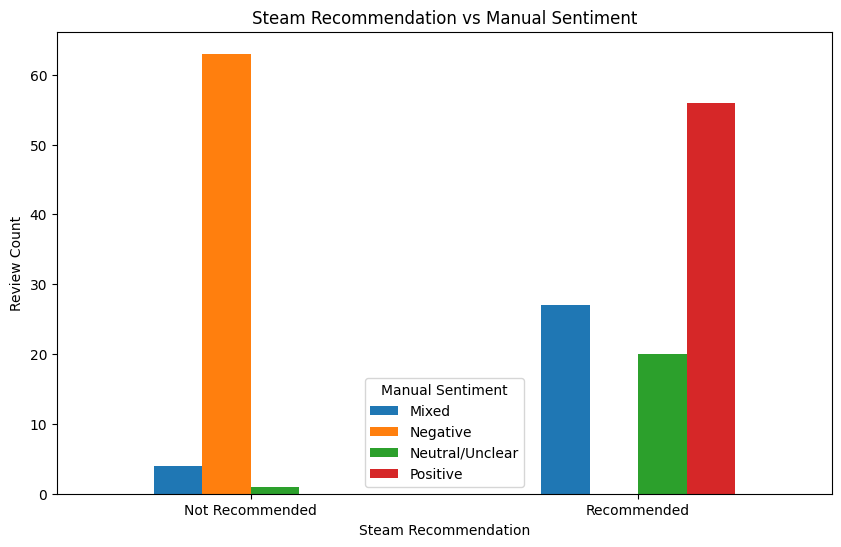

In [22]:
rec_vs_sentiment_count.plot(kind="bar")
plt.title("Steam Recommendation vs Manual Sentiment")
plt.xlabel("Steam Recommendation")
plt.ylabel("Review Count")
plt.xticks(rotation=0)
plt.legend(title="Manual Sentiment")
plt.show()

## 5. Baseline 0: Steam Label as Sentiment Predictor

This is the simplest baseline.

The simple assumption is:

```text
Recommended     → Positive
Not Recommended → Negative
```

This prediction is compared against the manually tagged `actual_sentiment`.

Because this baseline only has two classes, it is evaluated only on rows where:

```text
actual_sentiment ∈ {Positive, Negative}
```

In [23]:
binary_eval_df = df[
    df["actual_sentiment"].isin(["Positive", "Negative"])
].copy()

binary_eval_df["steam_label_sentiment"] = binary_eval_df["recommendation"].map({
    "Recommended": "Positive",
    "Not Recommended": "Negative"
})

binary_eval_df = binary_eval_df.dropna(subset=["steam_label_sentiment"])

steam_baseline_accuracy = accuracy_score(
    binary_eval_df["actual_sentiment"],
    binary_eval_df["steam_label_sentiment"]
)

print("Rows evaluated:", len(binary_eval_df))
print("Steam label baseline accuracy:", round(steam_baseline_accuracy, 4))

print("\nClassification report:")
print(
    classification_report(
        binary_eval_df["actual_sentiment"],
        binary_eval_df["steam_label_sentiment"],
        zero_division=0
    )
)

steam_cm = confusion_matrix(
    binary_eval_df["actual_sentiment"],
    binary_eval_df["steam_label_sentiment"],
    labels=["Negative", "Positive"]
)

steam_cm_df = pd.DataFrame(
    steam_cm,
    index=["Actual Negative", "Actual Positive"],
    columns=["Pred Negative", "Pred Positive"]
)

display(steam_cm_df)

Rows evaluated: 119
Steam label baseline accuracy: 1.0

Classification report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        63
    Positive       1.00      1.00      1.00        56

    accuracy                           1.00       119
   macro avg       1.00      1.00      1.00       119
weighted avg       1.00      1.00      1.00       119



,Pred Negative,Pred Positive
Actual Negative,63,0
Actual Positive,0,56


## 6. Prepare Model-Ready Dataset

This step creates several modeling targets:

1. `binary_sentiment_target`
   - only Positive vs Negative
   - more stable for the first baseline

2. `multiclass_sentiment_target`
   - Positive, Negative, Mixed, Neutral/Unclear
   - closer to the project question, but harder because each class has fewer rows

3. `mismatch_or_ambiguous_target`
   - whether the review is aligned or mismatch/ambiguous
   - optional, not the main target yet

In [24]:
model_df = df.copy()

model_df["word_count"] = model_df["analysis_review"].apply(lambda x: len(str(x).split()))
model_df["char_count"] = model_df["analysis_review"].apply(lambda x: len(str(x)))
model_df["log_playtime"] = np.log1p(pd.to_numeric(model_df["playtime_hours"], errors="coerce").fillna(0))

# Recompute mismatch type defensively
def recompute_mismatch_type(row):
    rec = row["recommendation"]
    actual = row["actual_sentiment"]

    if rec == "Recommended":
        if actual == "Negative":
            return "Hard Mismatch: Recommended but Negative Text"
        if actual == "Mixed":
            return "Soft Mismatch: Recommended but Mixed Text"
        if actual == "Neutral/Unclear":
            return "Ambiguous / Low Information"
        if actual == "Positive":
            return "Aligned Positive"

    if rec == "Not Recommended":
        if actual == "Positive":
            return "Hard Mismatch: Not Recommended but Positive Text"
        if actual == "Mixed":
            return "Soft Mismatch: Not Recommended but Mixed Text"
        if actual == "Neutral/Unclear":
            return "Ambiguous / Low Information"
        if actual == "Negative":
            return "Aligned Negative"

    return "Unknown"

model_df["mismatch_type_recomputed"] = model_df.apply(recompute_mismatch_type, axis=1)

model_df["is_mismatch_or_ambiguous_target"] = ~model_df[
    "mismatch_type_recomputed"
].isin([
    "Aligned Positive",
    "Aligned Negative"
])

model_df["binary_sentiment_target"] = np.where(
    model_df["actual_sentiment"].isin(["Positive", "Negative"]),
    model_df["actual_sentiment"],
    np.nan
)

model_df["multiclass_sentiment_target"] = model_df["actual_sentiment"]

model_df.to_csv(MODEL_READY_PATH, index=False)

print("Model-ready dataset saved to:")
print(MODEL_READY_PATH)

print("\nBinary target distribution:")
display(model_df["binary_sentiment_target"].value_counts(dropna=False))

print("\nMulticlass target distribution:")
display(model_df["multiclass_sentiment_target"].value_counts())

print("\nMismatch or ambiguous target distribution:")
display(model_df["is_mismatch_or_ambiguous_target"].value_counts())

Model-ready dataset saved to:
..\data\processed\combined_tagged_reviews_model_ready.csv

Binary target distribution:


binary_sentiment_target
Negative    63
Positive    56
NaN         52
Name: count, dtype: int64


Multiclass target distribution:


multiclass_sentiment_target
Negative           63
Positive           56
Mixed              31
Neutral/Unclear    21
Name: count, dtype: int64


Mismatch or ambiguous target distribution:


is_mismatch_or_ambiguous_target
False    119
True      52
Name: count, dtype: int64

## 7. Train/Test Helper Functions

These helper functions keep model evaluation consistent across different targets.

In [25]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score


def plot_confusion_matrix(cm, labels, title):
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm)

    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))

    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    plt.setp(
        ax.get_xticklabels(),
        rotation=45,
        ha="right",
        rotation_mode="anchor"
    )

    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )

    ax.set_title(title)
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")
    fig.tight_layout()
    plt.show()


def evaluate_text_model(
    data,
    target_col,
    model_name="Logistic Regression",
    estimator=None,
    test_size=0.25,
    random_state=42
):
    modeling_data = data[
        data[target_col].notna()
        &
        (data["analysis_review"].str.strip() != "")
    ].copy()

    class_counts = modeling_data[target_col].value_counts()

    print("Target distribution:")
    display(class_counts)

    if len(modeling_data) < 30:
        print("Not enough rows for reliable train/test split.")
        return None

    if class_counts.min() < 2:
        print("At least one class has fewer than 2 samples. Cannot stratify.")
        return None

    X = modeling_data["analysis_review"]
    y = modeling_data[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    if estimator is None:
        estimator = LogisticRegression(
            max_iter=2000,
            class_weight="balanced"
        )

    pipeline = Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                stop_words="english",
                ngram_range=(1, 2),
                min_df=2,
                max_features=5000
            )
        ),
        ("model", estimator)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    labels = sorted(y.unique().tolist())

    print(f"\n=== {model_name} ===")
    print("Train rows:", len(X_train))
    print("Test rows:", len(X_test))

    print("\nClassification report:")
    print(
        classification_report(
            y_test,
            y_pred,
            labels=labels,
            zero_division=0
        )
    )

    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(
        y_test,
        y_pred,
        labels=labels,
        average="macro",
        zero_division=0
    )

    print("Accuracy:", round(accuracy, 4))
    print("Macro F1:", round(macro_f1, 4))

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=labels
    )

    display(
        pd.DataFrame(
            cm,
            index=[f"Actual {label}" for label in labels],
            columns=[f"Pred {label}" for label in labels]
        )
    )

    plot_confusion_matrix(
        cm,
        labels,
        f"{model_name} Confusion Matrix"
    )

    predictions_df = pd.DataFrame({
        "analysis_review": X_test,
        "actual_label": y_test,
        "predicted_label": y_pred
    })

    return {
        "pipeline": pipeline,
        "predictions": predictions_df,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "labels": labels
    }

## 8. Baseline Model 1: Binary Sentiment

Target:

```text
Positive vs Negative
```

This is the most stable baseline because it excludes `Mixed` and `Neutral/Unclear` rows.

This result is used as the main baseline.

Target distribution:


binary_sentiment_target
Negative    63
Positive    56
Name: count, dtype: int64


=== TF-IDF + Logistic Regression (Binary Sentiment) ===
Train rows: 89
Test rows: 30

Classification report:
              precision    recall  f1-score   support

    Negative       0.83      0.94      0.88        16
    Positive       0.92      0.79      0.85        14

    accuracy                           0.87        30
   macro avg       0.88      0.86      0.86        30
weighted avg       0.87      0.87      0.87        30

Accuracy: 0.8667
Macro F1: 0.8643


,Pred Negative,Pred Positive
Actual Negative,15,1
Actual Positive,3,11


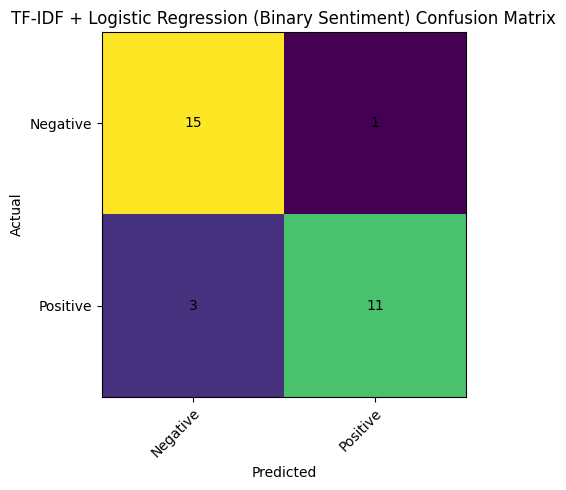

Binary predictions saved to:
..\data\processed\binary_sentiment_predictions.csv


In [26]:
binary_result = evaluate_text_model(
    data=model_df,
    target_col="binary_sentiment_target",
    model_name="TF-IDF + Logistic Regression (Binary Sentiment)",
    estimator=LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    )
)

if binary_result is not None:
    binary_predictions = binary_result["predictions"].copy()
    binary_predictions.to_csv(BINARY_PREDICTIONS_PATH, index=False)

    print("Binary predictions saved to:")
    print(BINARY_PREDICTIONS_PATH)

## 9. Compare Text Model vs Steam Label Baseline

This section compares:

```text
Steam label baseline
vs
TF-IDF text model
```

If the text model approaches or beats the Steam-label baseline, it suggests that review text contains learnable sentiment signals.

If the Steam-label baseline is stronger, that is also useful: it suggests that Steam labels are reliable for coarse polarity, but still do not explain `Mixed` and `Neutral/Unclear` reviews.

In [27]:
if binary_result is not None:
    comparison = pd.DataFrame([
        {
            "method": "Steam Recommendation Baseline",
            "accuracy": steam_baseline_accuracy,
            "macro_f1": np.nan
        },
        {
            "method": "TF-IDF + Logistic Regression",
            "accuracy": binary_result["accuracy"],
            "macro_f1": binary_result["macro_f1"]
        }
    ])

    display(comparison)
else:
    print("Binary model was not trained, so comparison is unavailable.")

,method,accuracy,macro_f1
0,Steam Recommendation Baseline,1.000000,NaN
1,TF-IDF + Logistic Regression,0.866667,0.864253


## 10. Inspect Wrong Predictions

Wrong predictions are often more informative than accuracy alone.

The error examples are checked for patterns such as:

- sarcasm
- meme review
- mixed sentiment
- short low-information review
- update backlash with positive nostalgia

In [28]:
if binary_result is not None:
    wrong_predictions = binary_result["predictions"][
        binary_result["predictions"]["actual_label"]
        !=
        binary_result["predictions"]["predicted_label"]
    ].copy()

    print("Wrong predictions:", len(wrong_predictions))

    display(
        wrong_predictions[
            [
                "actual_label",
                "predicted_label",
                "analysis_review"
            ]
        ].head(20)
    )
else:
    print("Binary model was not trained.")

Wrong predictions: 4


,actual_label,predicted_label,analysis_review
155,Negative,Positive,this game suck
69,Positive,Negative,the only thing i was certain was the what ever it was it wanted me gone 10/10
133,Positive,Negative,the grass was to green so i knew it was a jyn my freind said nah we whent insinde and i had ghostdih go in to a bad place in my body 10/10 experince i would do again
42,Positive,Negative,played this game since early release days and im still in love with every aspect of the game


## 11. Interpretability: Top Terms for Positive vs Negative

Because the baseline uses Logistic Regression with TF-IDF, the strongest terms can be inspected.

This makes the model easier to explain in a portfolio context.

In [29]:
if binary_result is not None:
    pipeline = binary_result["pipeline"]

    vectorizer = pipeline.named_steps["tfidf"]
    classifier = pipeline.named_steps["model"]

    feature_names = vectorizer.get_feature_names_out()
    classes = classifier.classes_

    print("Classes:", classes)

    if len(classes) == 2:
        coef = classifier.coef_[0]

        # For binary logistic regression, positive coefficients favor classes_[1]
        positive_class = classes[1]
        negative_class = classes[0]

        top_positive_idx = np.argsort(coef)[-20:][::-1]
        top_negative_idx = np.argsort(coef)[:20]

        top_positive_terms = pd.DataFrame({
            "term": feature_names[top_positive_idx],
            "coefficient": coef[top_positive_idx],
            "favored_class": positive_class
        })

        top_negative_terms = pd.DataFrame({
            "term": feature_names[top_negative_idx],
            "coefficient": coef[top_negative_idx],
            "favored_class": negative_class
        })

        print("\nTop terms favoring:", positive_class)
        display(top_positive_terms)

        print("\nTop terms favoring:", negative_class)
        display(top_negative_terms)
    else:
        print("Binary coefficient interpretation unavailable because model has more than 2 classes.")
else:
    print("Binary model was not trained.")

Classes: ['Negative' 'Positive']

Top terms favoring: Positive


,term,coefficient,favored_class
0,fun,1.028501,Positive
1,good,0.842379,Positive
2,scary,0.789336,Positive
3,friends,0.713403,Positive
4,best,0.691738,Positive
5,ghost,0.642860,Positive
6,play,0.601484,Positive
7,yes,0.525020,Positive
8,funny,0.463850,Positive
9,play friends,0.407547,Positive



Top terms favoring: Negative


,term,coefficient,favored_class
0,update,-1.221169,Negative
1,animations,-0.710647,Negative
2,ruined,-0.670845,Negative
3,just,-0.638310,Negative
4,worse,-0.636202,Negative
5,updates,-0.525221,Negative
6,bugs,-0.508272,Negative
7,unplayable,-0.489912,Negative
8,latest,-0.464126,Negative
9,time,-0.449390,Negative


## 12. Optional Model 2: Multiclass Sentiment

Target:

```text
Positive
Negative
Mixed
Neutral/Unclear
```

This target is closer to the project goal, but it is harder because the dataset is still small and class imbalance is more visible.

The result should be treated as an experiment, not the main claim.

Target distribution:


multiclass_sentiment_target
Negative           63
Positive           56
Mixed              31
Neutral/Unclear    21
Name: count, dtype: int64


=== TF-IDF + Logistic Regression (Multiclass Sentiment) ===
Train rows: 128
Test rows: 43

Classification report:
                 precision    recall  f1-score   support

          Mixed       0.30      0.38      0.33         8
       Negative       0.83      0.94      0.88        16
Neutral/Unclear       0.67      0.80      0.73         5
       Positive       0.67      0.43      0.52        14

       accuracy                           0.65        43
      macro avg       0.62      0.64      0.62        43
   weighted avg       0.66      0.65      0.64        43

Accuracy: 0.6512
Macro F1: 0.6162


,Pred Mixed,Pred Negative,Pred Neutral/Unclear,Pred Positive
Actual Mixed,3,2,1,2
Actual Negative,1,15,0,0
Actual Neutral/Unclear,0,0,4,1
Actual Positive,6,1,1,6


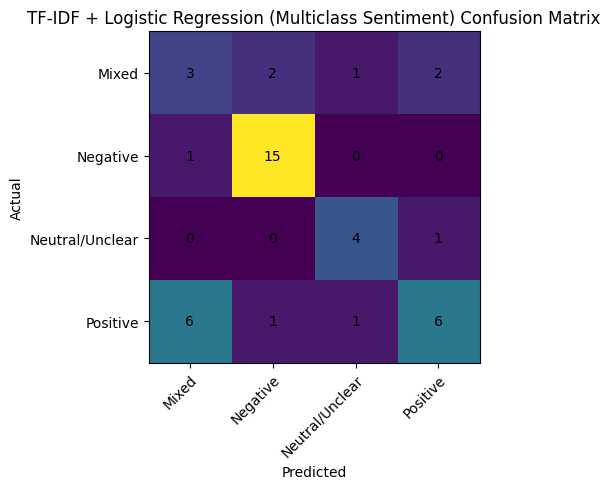

Multiclass predictions saved to:
..\data\processed\multiclass_sentiment_predictions.csv


In [30]:
multiclass_result = evaluate_text_model(
    data=model_df,
    target_col="multiclass_sentiment_target",
    model_name="TF-IDF + Logistic Regression (Multiclass Sentiment)",
    estimator=LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
    )
)

if multiclass_result is not None:
    multiclass_predictions = multiclass_result["predictions"].copy()
    multiclass_predictions.to_csv(MULTICLASS_PREDICTIONS_PATH, index=False)

    print("Multiclass predictions saved to:")
    print(MULTICLASS_PREDICTIONS_PATH)

## 13. Optional Model 3: Mismatch or Ambiguous Detector

Target:

```text
Aligned
vs
Mismatch / Ambiguous
```

This is not the main target yet because the `Mismatch / Ambiguous` group is heterogeneous.

However, it can still be useful for dashboarding or future work.

Target distribution:


mismatch_binary_target
Aligned                  119
Mismatch_or_Ambiguous     52
Name: count, dtype: int64


=== TF-IDF + Logistic Regression (Mismatch or Ambiguous) ===
Train rows: 128
Test rows: 43

Classification report:
                       precision    recall  f1-score   support

              Aligned       0.83      0.83      0.83        30
Mismatch_or_Ambiguous       0.62      0.62      0.62        13

             accuracy                           0.77        43
            macro avg       0.72      0.72      0.72        43
         weighted avg       0.77      0.77      0.77        43

Accuracy: 0.7674
Macro F1: 0.7244


,Pred Aligned,Pred Mismatch_or_Ambiguous
Actual Aligned,25,5
Actual Mismatch_or_Ambiguous,5,8


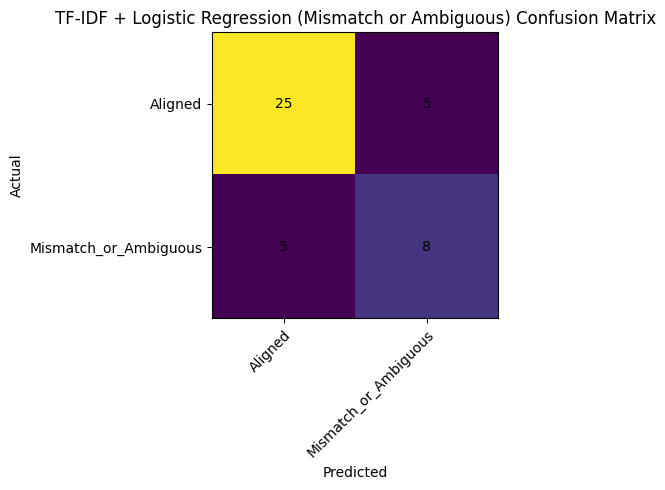

In [31]:
mismatch_model_df = model_df.copy()
mismatch_model_df["mismatch_binary_target"] = np.where(
    mismatch_model_df["is_mismatch_or_ambiguous_target"],
    "Mismatch_or_Ambiguous",
    "Aligned"
)

mismatch_result = evaluate_text_model(
    data=mismatch_model_df,
    target_col="mismatch_binary_target",
    model_name="TF-IDF + Logistic Regression (Mismatch or Ambiguous)",
    estimator=LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    )
)

## 14. Save Baseline Model

The main binary baseline model is saved as a `.joblib` file.

This can be reused later for simple inference or a small demo.

In [32]:
try:
    import joblib

    if binary_result is not None:
        joblib.dump(binary_result["pipeline"], MODEL_PATH)

        print("Binary baseline model saved to:")
        print(MODEL_PATH)
    else:
        print("Binary model was not trained, so no model was saved.")

except ImportError:
    print("joblib is not installed. Install it with:")
    print("pip install joblib")

Binary baseline model saved to:
..\models\baseline_binary_sentiment_tfidf_logreg.joblib


## 15. Interim Conclusion Template

After running the notebook, the interpretation should stay conservative. A safe summary is:

```text
The Steam recommendation label performs well for coarse binary polarity, especially for Not Recommended reviews. However, manual tagging shows that Recommended reviews are more ambiguous, frequently including mixed sentiment, jokes, low-information text, or positive reviews with complaints.

The TF-IDF baseline provides an interpretable text-based model for predicting manual sentiment, but the dataset is still small. Therefore, the model should be treated as an initial baseline rather than a production-level classifier.
```

Possible next phase:

```text
06_dashboard_dataset_prep.ipynb
```

or:

```text
06_model_error_analysis_and_improvement.ipynb
```